# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the Data

In [49]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Initial Inspection

In [51]:
# View first 5 rows
df.head()

# Data types & non-null counts
df.info()

# Summary stats for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Missing Values Check

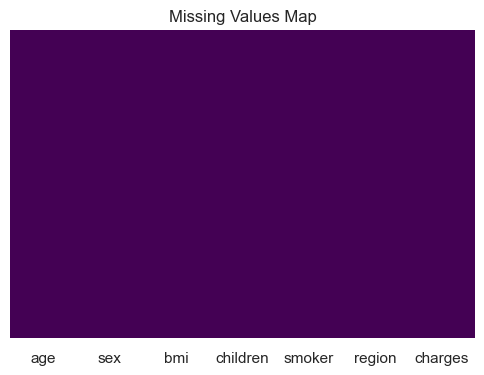

In [53]:
# Count nulls per column
df.isnull().sum()

# Visualize missingness
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Map")
plt.show()

In [9]:
# Insight - There are No Missing values in this dataset.

# Univariate Analysis

Text(0.5, 1.0, 'Smoker vs Non-Smoker Count')

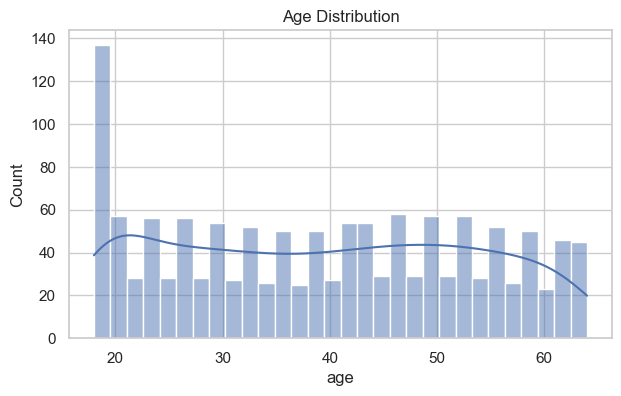

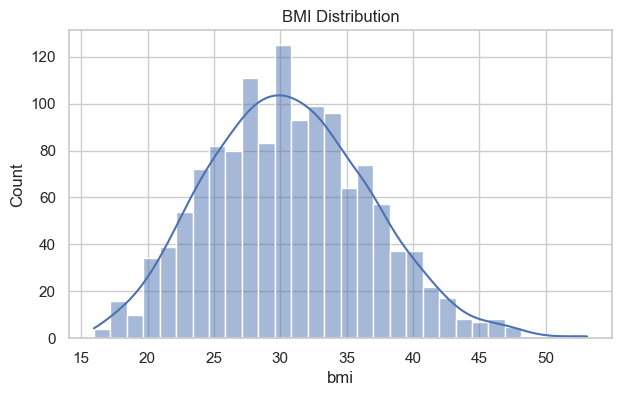

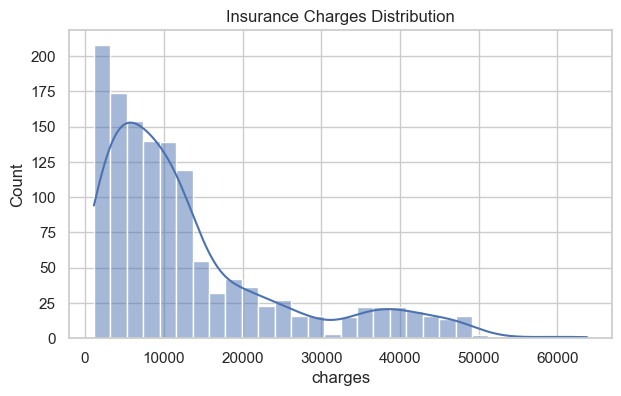

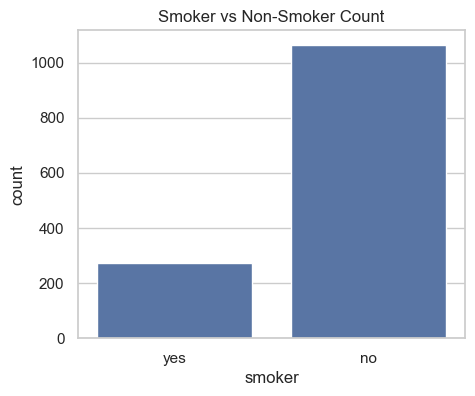

In [12]:
# Age distribution
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")

# BMI distribution
plt.figure(figsize=(7,4))
sns.histplot(df["bmi"], bins=30, kde=True)
plt.title("BMI Distribution")

# Charges distribution
plt.figure(figsize=(7,4))
sns.histplot(df["charges"], bins=30, kde=True)
plt.title("Insurance Charges Distribution")

# Count of smokers vs non-smokers
plt.figure(figsize=(5,4))
sns.countplot(x="smoker", data=df)
plt.title("Smoker vs Non-Smoker Count")

Text(0.5, 1.0, 'Average Charges by # of Children')

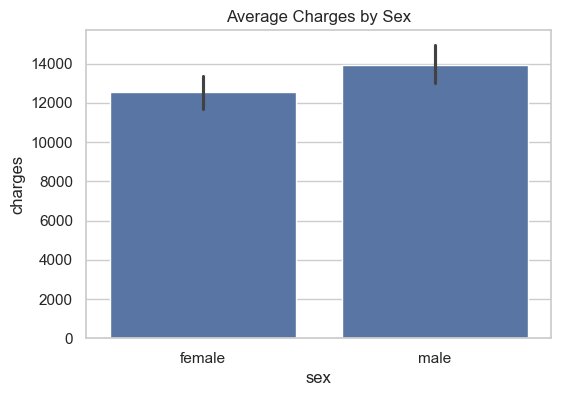

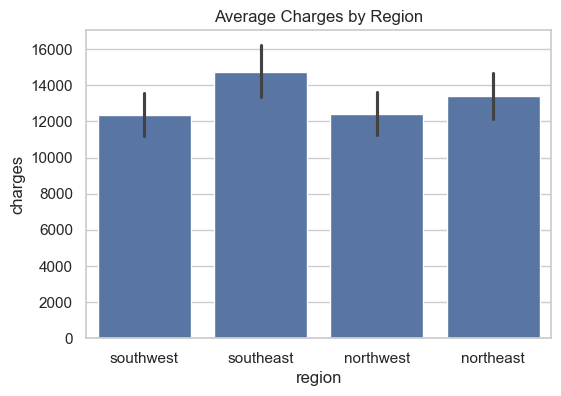

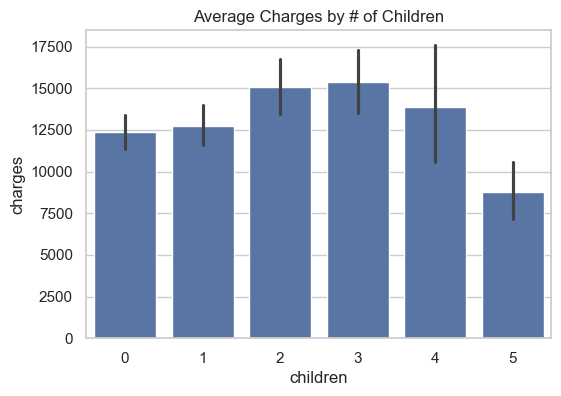

In [14]:
# Average charges by sex
plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="charges", data=df)
plt.title("Average Charges by Sex")

# Average charges by region
plt.figure(figsize=(6,4))
sns.barplot(x="region", y="charges", data=df)
plt.title("Average Charges by Region")

# Average charges by number of children
plt.figure(figsize=(6,4))
sns.barplot(x="children", y="charges", data=df)
plt.title("Average Charges by # of Children")

# Smoking Effect

C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_1732\4098224794.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.smoker=="yes"].charges, label="Smoker", shade=True)
C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_1732\4098224794.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df.smoker=="no"].charges, label="Non-Smoker", shade=True)


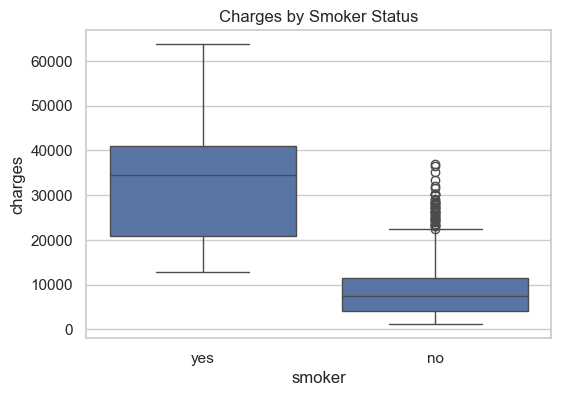

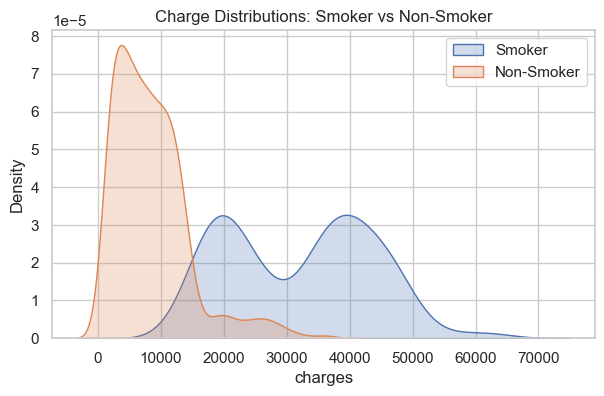

In [18]:
# Boxplot of charges by smoker status
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoker Status")

# Distribution of charges for smokers vs non-smokers
plt.figure(figsize=(7,4))
sns.kdeplot(df[df.smoker=="yes"].charges, label="Smoker", shade=True)
sns.kdeplot(df[df.smoker=="no"].charges, label="Non-Smoker", shade=True)
plt.title("Charge Distributions: Smoker vs Non-Smoker")
plt.legend()

# Feature Engineering

Text(0.5, 1.0, 'Average Charges by BMI Category')

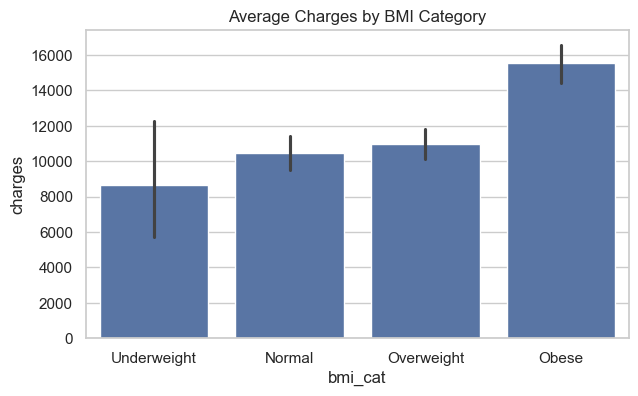

In [20]:
# BMI categories
bins = [0, 18.5, 25, 30, np.inf]
labels = ["Underweight","Normal","Overweight","Obese"]
df["bmi_cat"] = pd.cut(df["bmi"], bins=bins, labels=labels)

# Average charges by BMI category
plt.figure(figsize=(7,4))
sns.barplot(x="bmi_cat", y="charges", data=df, order=labels)
plt.title("Average Charges by BMI Category")

In [24]:
print(corr_df.dtypes)

age            int64
sex            int64
bmi          float64
children       int64
smoker         int64
region       float64
charges      float64
bmi_cat     category
dtype: object


# Correlation & Heatmap

Text(0.5, 1.0, 'Feature Correlation Heatmap')

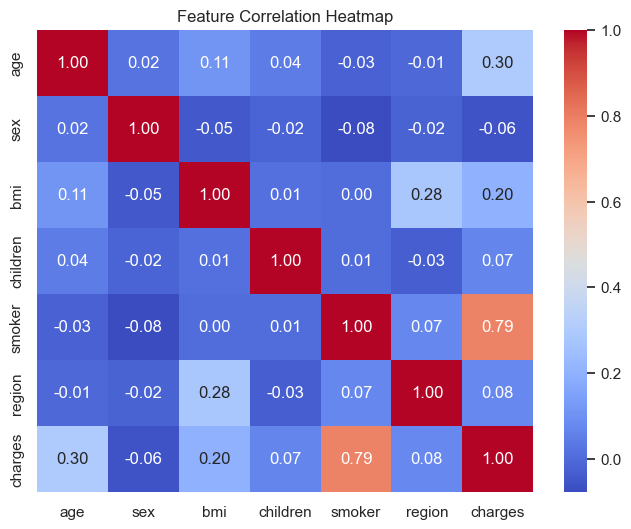

In [32]:
import numpy as np

# Make a fresh copy
corr_df = df.copy()

# Encode the existing categoricals
corr_df["sex"]    = corr_df["sex"].map({"male":0, "female":1})
corr_df["smoker"] = corr_df["smoker"].map({"no":0, "yes":1})
corr_df["region"] = corr_df["region"].map({
    "south":0, "northwest":1, "northeast":2, "southeast":3
})

# Drop the bmi_cat text labels
corr_df = corr_df.drop(columns=["bmi_cat"])

# Now select only numeric columns and corr()
num_df = corr_df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")

# Pairwise Relationships

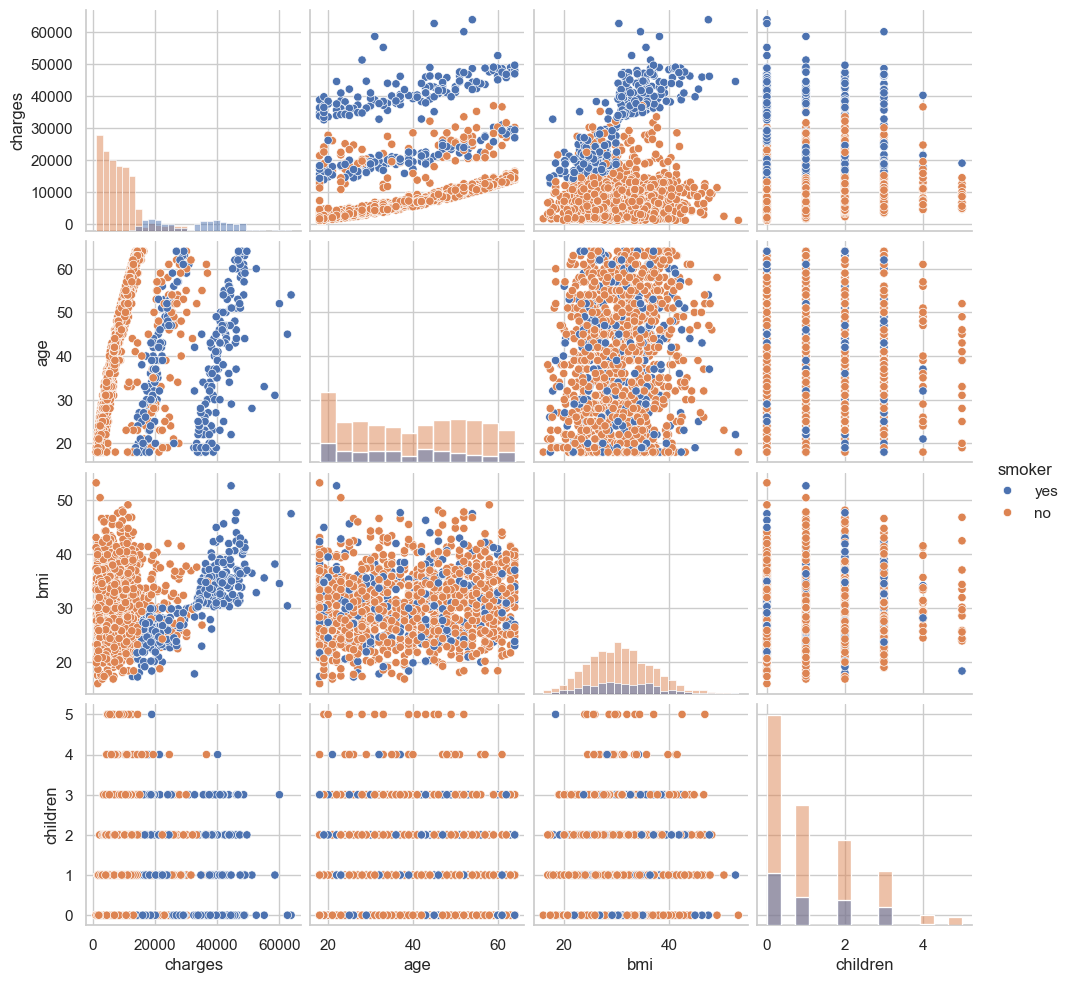

In [34]:
# Pairplot of key features colored by smoker
sns.pairplot(df[["charges","age","bmi","children","smoker"]], hue="smoker", diag_kind="hist")

# OBSERVATIONS

In [38]:
#1 Smokers incur dramatically higher charges than non-smokers.

#2 BMI and age both positively correlate with charges.

#3 Those in the “Obese” category pay noticeably more than “Normal.”

#4 Regions show minor variation in average charges.

#5 Number of children has only a slight effect.